# Notebook 4 – Activation Functions

**File Name:** `04_Activation_Functions.ipynb`

---

# 1. What is an Activation Function?

## Simple Concept

An **activation function** decides how strongly a neuron should be activated.

A neuron first calculates:

```text
z = w₁x₁ + w₂x₂ + ... + b
```

Then the activation function converts `z` into the neuron's final output:

```text
output = activation(z)
```

So:

```text
Inputs → Weighted Sum → Activation Function → Output
```

---

# 2. Why Do We Need Activation Functions?

This is one of the **most important concepts in neural networks**.

## Simple Explanation

Without an activation function, a neural network would behave almost like a **simple linear model**, even if we add many layers.

For example:

```text
Input → Linear Layer → Linear Layer → Output
```

If every layer only performs a linear calculation, the entire network can still be simplified into one linear calculation.

So the network would have difficulty learning **complex patterns**.

### Example

Imagine we want to identify whether a picture contains a cat.

The decision may depend on:

* Ear shape
* Eye shape
* Nose shape
* Face shape
* Fur pattern

These relationships are not simply linear.

Activation functions introduce **non-linearity**.

Therefore:

```text
Without activation:
Network → mostly linear relationships

With activation:
Network → can learn complex/non-linear relationships
```

### Very Simple Example

Think of an activation function like a **decision gate**.

```text
Large useful signal  → allow strongly
Small signal          → reduce
Negative signal       → possibly block
```

This allows neurons in different layers to learn different patterns.

## Key Point

> **Activation functions allow neural networks to learn non-linear and complex patterns.**

Without activation functions, adding many neural-network layers would provide much less benefit.

---

# 3. Sigmoid

## Simple Concept

Sigmoid converts any input into a value between:

```text
0 and 1
```

It is especially useful when we want to interpret the output as a probability.

---

## Formula

```text
σ(z) = 1 / (1 + e⁻ᶻ)
```

---

## Range

```text
0 < Sigmoid(z) < 1
```

Example:

```text
z = -5 → approximately 0.007
z =  0 → 0.5
z =  5 → approximately 0.993
```

So sigmoid converts a large negative value close to `0` and a large positive value close to `1`.

---


## Advantages

* Output is between `0` and `1`
* Easy to interpret as probability
* Useful for binary classification output layers

---

## Limitations

The main problem is **vanishing gradients**.

When the input becomes very positive or very negative, the sigmoid curve becomes almost flat.

When the curve becomes flat:

```text
Gradient becomes very small
        ↓
Weight updates become very small
        ↓
Learning becomes slow
```

This is called the:

**Vanishing Gradient Problem**

---

# 4. Tanh

## Simple Concept

Tanh is similar to sigmoid, but its output is centered around `0`.

---

## Formula

```text
tanh(z) = (eᶻ - e⁻ᶻ) / (eᶻ + e⁻ᶻ)
```

---

## Range

```text
-1 to +1
```

Example:

```text
Large negative input → close to -1
Input = 0            → 0
Large positive input → close to +1
```

---


---

## Advantages

### 1. Output is centered around zero

```text
Negative → negative output
Zero     → zero output
Positive → positive output
```

This can make optimization easier than sigmoid in some situations.

### 2. Stronger output range

Tanh produces values between:

```text
-1 and +1
```

---

## Limitations

Tanh can also suffer from:

**Vanishing gradients**

When inputs become very large or very small, the curve becomes flat and gradients become very small.

---

# 5. ReLU

## Simple Concept

ReLU stands for:

**Rectified Linear Unit**

It is one of the most commonly used activation functions in neural networks.

---

## Formula

```text
ReLU(z) = max(0, z)
```

---

## How ReLU Works

```text
Negative input → 0
Positive input → same value
```

Examples:

```text
ReLU(-5) = 0
ReLU(-2) = 0
ReLU(0)  = 0
ReLU(3)  = 3
ReLU(8)  = 8
```



---

# 6. Why Did ReLU Become Popular?

ReLU became popular because it is:

### Simple

The calculation is very simple:

```text
max(0, x)
```

### Fast

It is computationally cheap compared with functions such as sigmoid and tanh.

### Helps with vanishing gradients

For positive inputs, ReLU has a gradient of approximately:

```text
1
```

So positive signals can continue propagating through the network effectively.

### Useful for Deep Neural Networks

ReLU became widely used in hidden layers of deep neural networks.

---

# 7. Dying ReLU Problem

ReLU has one important problem.

Consider:

```text
ReLU(-5) = 0
ReLU(-3) = 0
ReLU(-1) = 0
```

For negative inputs, the gradient is `0`.

If a neuron consistently receives negative values:

```text
Neuron output → 0
       ↓
Gradient → 0
       ↓
Weights may stop updating
       ↓
Neuron may become inactive
```

This is called the:

**Dying ReLU Problem**

The neuron can effectively stop contributing to learning.

---

# 8. Leaky ReLU

## Simple Concept

Leaky ReLU was introduced to reduce the **dying ReLU problem**.

Instead of making every negative input exactly `0`, Leaky ReLU allows a **small negative value** to pass through.

---

## Formula

```text
LeakyReLU(z) = z       if z > 0
               αz      if z ≤ 0
```

Usually:

```text
α = 0.01
```

---

## Example

With `α = 0.01`:

```text
Input = -5

ReLU:
0

Leaky ReLU:
-0.05
```

So the neuron still receives a small signal.

---



---

# 9. ReLU vs Leaky ReLU

| Feature            | ReLU          | Leaky ReLU           |
| ------------------ | ------------- | -------------------- |
| Positive input     | Same value    | Same value           |
| Negative input     | 0             | Small negative value |
| Simple             | Yes           | Yes                  |
| Dying ReLU problem | Possible      | Reduced              |
| Common use         | Hidden layers | Hidden layers        |

### Easy Way to Remember

```text
ReLU:
Negative → 0

Leaky ReLU:
Negative → small value
```

---

# 10. Softmax

## Simple Concept

Softmax is mainly used for **multiclass classification**.

It converts multiple output scores into probabilities.

The probabilities add up to:

```text
1
```

---

## Example

Suppose a model predicts three classes:

```text
Cat
Dog
Horse
```

The neural network may produce raw scores:

```text
Cat   = 2.0
Dog   = 1.0
Horse = 0.1
```

Softmax converts these scores into probabilities such as:

```text
Cat   → 0.66
Dog   → 0.24
Horse → 0.10
```

The exact values depend on the scores.

And:

```text
0.66 + 0.24 + 0.10 = 1.00
```

---

## Formula

For class `i`:

```text
Softmax(zᵢ) = eᶻⁱ / Σeᶻʲ
```

The denominator considers the scores of **all classes**.

---

## Python Example

```python
import numpy as np

scores = np.array([2.0, 1.0, 0.1])

exp_scores = np.exp(scores)

probabilities = exp_scores / np.sum(exp_scores)

print(probabilities)
print("Sum:", np.sum(probabilities))
```

### Example Output

```text
[0.65900114 0.24243297 0.09856589]
Sum: 1.0
```

---

# 11. Probability Interpretation

Softmax allows us to interpret the model's output as a probability distribution.

For example:

```text
Cat    → 65.9%
Dog    → 24.2%
Horse  → 9.9%
```

The highest probability is:

```text
Cat
```

So the model predicts:

```text
Cat
```

---

# 12. When Do We Use Softmax?

Softmax is commonly used when there are **multiple mutually exclusive classes**.

Examples:

```text
Image → Cat / Dog / Horse

Email → Work / Personal / Promotion

News → Sports / Business / Politics / Technology
```

---

# 13. Important Difference: Sigmoid vs Softmax

### Sigmoid

Usually used for:

```text
Binary classification
```

Example:

```text
Spam
Not Spam
```

Output:

```text
0.92
```

This can be interpreted as the probability of the positive class.

### Softmax

Used for:

```text
Multiclass classification
```

Example:

```text
Cat
Dog
Horse
```

Outputs:

```text
Cat   → 0.70
Dog   → 0.20
Horse → 0.10
```

---

# 14. Activation Function Comparison

| Activation | Output Range | Common Use         | Main Advantage             | Main Problem                       |
| ---------- | -----------: | ------------------ | -------------------------- | ---------------------------------- |
| Sigmoid    |       0 to 1 | Binary output      | Probability interpretation | Vanishing gradient                 |
| Tanh       |      -1 to 1 | Some hidden layers | Zero-centered              | Vanishing gradient                 |
| ReLU       |       0 to ∞ | Hidden layers      | Simple and efficient       | Dying ReLU                         |
| Leaky ReLU |      -∞ to ∞ | Hidden layers      | Reduces dying ReLU         | Still has limitations              |
| Softmax    |       0 to 1 | Multiclass output  | Class probabilities        | Not normally used in hidden layers |

---

# 15. Simple Mental Picture

Remember them like this:

```text
Sigmoid
      S-shaped
      0 → 1

Tanh
      S-shaped
      -1 → +1

ReLU
      Negative → 0
      Positive → same value

Leaky ReLU
      Negative → small negative value
      Positive → same value

Softmax
      Multiple scores
            ↓
      Probabilities
            ↓
      Sum = 1
```

---

# 16. Which Activation Function Should We Use?

A simple beginner rule:

### Hidden Layers

Usually start with:

```text
ReLU
```

or:

```text
Leaky ReLU
```

### Binary Classification Output

Often:

```text
Sigmoid
```

### Multiclass Classification Output

Often:

```text
Softmax
```

### Tanh

Useful in some neural-network architectures, especially where a zero-centered activation is useful.

---

# 17. Practical Example

Imagine we are building an image classification neural network.

```text
Image
  ↓
Input Layer
  ↓
Linear Layer
  ↓
ReLU
  ↓
Linear Layer
  ↓
ReLU
  ↓
Linear Layer
  ↓
Softmax
  ↓
Cat / Dog / Horse
```

Here:

```text
ReLU
↓
helps hidden layers learn complex patterns
```

and:

```text
Softmax
↓
converts final class scores into probabilities
```

---

# 18. Final Understanding

The most important idea from this notebook is:

```text
Activation functions introduce non-linearity.
```

Without activation functions:

```text
Neural Network
      ↓
Mostly linear transformations
      ↓
Limited ability to learn complex patterns
```

With activation functions:

```text
Neural Network
      ↓
Linear transformation
      ↓
Activation
      ↓
Non-linearity
      ↓
Complex pattern learning
```

### One-Line Memory Trick

```text
Activation Function = allows a neural network to learn complex, non-linear patterns.
```

---

# 19. Key Points

* Activation functions are used after the neuron's weighted sum.
* They introduce **non-linearity**.
* Without them, deep networks would behave much more like linear models.
* **Sigmoid** → output between `0` and `1`.
* **Tanh** → output between `-1` and `1`.
* **ReLU** → negative values become `0`.
* **Leaky ReLU** → keeps a small negative value.
* **Softmax** → converts multiple class scores into probabilities.
* Sigmoid and Tanh can suffer from **vanishing gradients**.
* ReLU can suffer from the **dying ReLU problem**.
* ReLU is commonly used in hidden layers.
* Sigmoid is commonly used for binary classification output.
* Softmax is commonly used for multiclass classification output.

---

# Final Flow to Remember

```text
Neuron calculates:

z = w₁x₁ + w₂x₂ + ... + b

        ↓

Activation Function

        ↓

output = activation(z)

        ↓

Next layer
```

The activation function is what gives the neural network the ability to learn **non-linear relationships and complex patterns**.


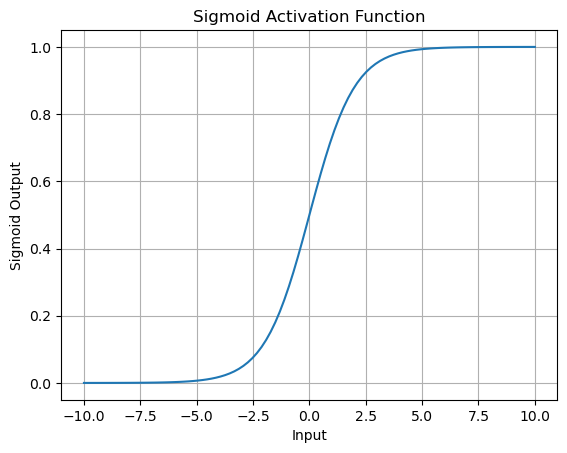

In [1]:
## Python Example

import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 100)

y = sigmoid(x)

plt.plot(x, y)
plt.xlabel("Input")
plt.ylabel("Sigmoid Output")
plt.title("Sigmoid Activation Function")
plt.grid()
plt.show()


## What the Graph Tells Us

The graph has an **S shape**.

```text
Large negative input → output close to 0
Input = 0            → output = 0.5
Large positive input → output close to 1
```

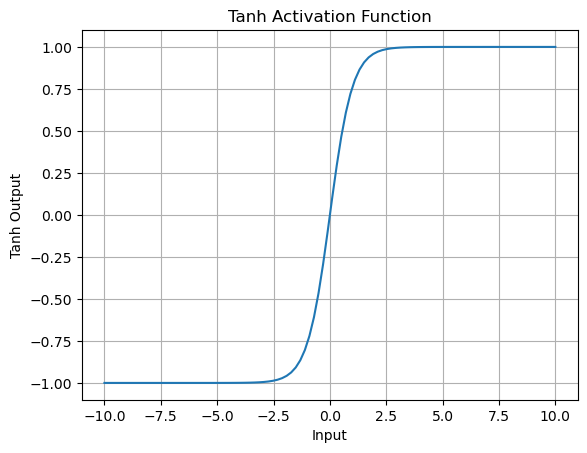

In [4]:
#Tanh
## Python Example

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)

y = np.tanh(x)

plt.plot(x, y)
plt.xlabel("Input")
plt.ylabel("Tanh Output")
plt.title("Tanh Activation Function")
plt.grid()
plt.show()


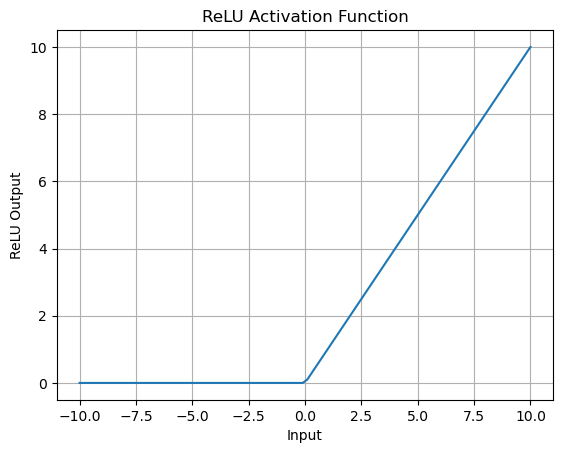

In [6]:
#ReLu
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)

y = np.maximum(0, x)

plt.plot(x, y)
plt.xlabel("Input")
plt.ylabel("ReLU Output")
plt.title("ReLU Activation Function")
plt.grid()
plt.show()


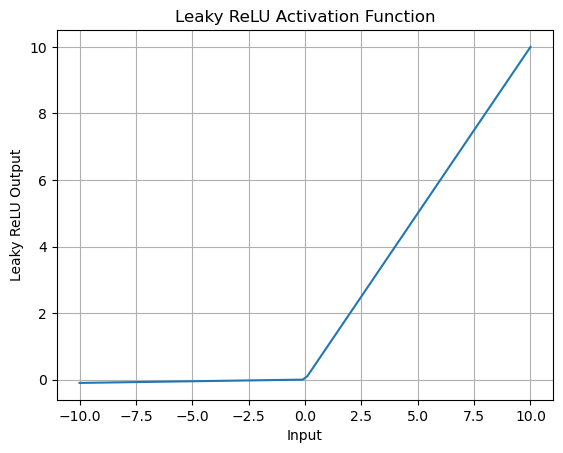

In [9]:
#Leaky ReLu
## Python Example

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)

alpha = 0.01

y = np.where(x > 0, x, alpha * x)

plt.plot(x, y)
plt.xlabel("Input")
plt.ylabel("Leaky ReLU Output")
plt.title("Leaky ReLU Activation Function")
plt.grid()
plt.show()
